In [13]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.patches as patches

In [14]:
non_pawn_row = ['toren', 'paard', 'loper', 'koningin', 'koning', 'loper', 'paard', 'toren']
pawn_row = ['pion' for _ in range(8)]
empty_row = ['leeg' for _ in range(8)]

In [31]:
bord = [[['zwart', p] for p in non_pawn_row], [['zwart', p] for p in pawn_row], empty_row, empty_row, empty_row, empty_row, [['wit', p] for p in pawn_row], [['wit', p] for p in non_pawn_row]]

In [32]:
bord

[[['zwart', 'toren'],
  ['zwart', 'paard'],
  ['zwart', 'loper'],
  ['zwart', 'koningin'],
  ['zwart', 'koning'],
  ['zwart', 'loper'],
  ['zwart', 'paard'],
  ['zwart', 'toren']],
 [['zwart', 'pion'],
  ['zwart', 'pion'],
  ['zwart', 'pion'],
  ['zwart', 'pion'],
  ['zwart', 'pion'],
  ['zwart', 'pion'],
  ['zwart', 'pion'],
  ['zwart', 'pion']],
 ['leeg', 'leeg', 'leeg', 'leeg', 'leeg', 'leeg', 'leeg', 'leeg'],
 ['leeg', 'leeg', 'leeg', 'leeg', 'leeg', 'leeg', 'leeg', 'leeg'],
 ['leeg', 'leeg', 'leeg', 'leeg', 'leeg', 'leeg', 'leeg', 'leeg'],
 ['leeg', 'leeg', 'leeg', 'leeg', 'leeg', 'leeg', 'leeg', 'leeg'],
 [['wit', 'pion'],
  ['wit', 'pion'],
  ['wit', 'pion'],
  ['wit', 'pion'],
  ['wit', 'pion'],
  ['wit', 'pion'],
  ['wit', 'pion'],
  ['wit', 'pion']],
 [['wit', 'toren'],
  ['wit', 'paard'],
  ['wit', 'loper'],
  ['wit', 'koningin'],
  ['wit', 'koning'],
  ['wit', 'loper'],
  ['wit', 'paard'],
  ['wit', 'toren']]]

In [20]:
bord[7][3]

['wit', 'koningin']

In [21]:
def toon_bord(board):

    images = []

    for i in range(8):  
        for j in range(8):
            piece = board[i][j]
            if piece == 'leeg':
                images.append(Image.open("icons/leeg.png"))
            else:
                images.append(Image.open(f"icons/{piece[0]}_{piece[1]}.png"))
                
    rows, cols = 8, 8
    
    # row + column labels
    row_labels = ['8', '7', '6', '5', '4', '3', '2', '1']
    col_labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']
    
    fig, axes = plt.subplots(
        rows, cols,
        figsize=(cols, rows),
        gridspec_kw=dict(wspace=0, hspace=0),
        #sharex=True, sharey=True,
    )
    
    axes = np.array(axes)
    
    # ===== 1. Show images, remove ticks =====
    for idx, img in enumerate(images):
        r, c = divmod(idx, cols)
        ax = axes[r, c]
        ax.imshow(img)
        ax.set_xticks([])
        ax.set_yticks([])
    
    # ===== 2. Add ROW LABELS on the left of each row =====
    for r in range(rows):
        ax = axes[r, 0]
        ax.set_ylabel(
            row_labels[r],
            rotation=0,
            labelpad=20,              # pushes label leftward
            va="center",
            ha="center"
        )
    
    # ===== 3. Add COLUMN LABELS centered under each column =====
    for c in range(cols):
        ax = axes[rows-1, c]
        ax.set_xlabel(
            col_labels[c],
            labelpad=20,             # pushes label downward
            ha="center",
            va="center"
        )
    
    # ===== 4. Build roster gridlines using spines =====
    # Hide all spines first
    for ax in axes.ravel():
        for s in ax.spines.values():
            s.set_visible(False)
    
    # Turn on only the necessary ones
    for r in range(rows):
        for c in range(cols):
            ax = axes[r, c]
    
            # outer border
            if r == 0:
                ax.spines["top"].set_visible(True)
            if r == rows - 1:
                ax.spines["bottom"].set_visible(True)
            if c == 0:
                ax.spines["left"].set_visible(True)
            if c == cols - 1:
                ax.spines["right"].set_visible(True)
    
            # inner grid lines (each one drawn once)
            if r < rows - 1:
                ax.spines["bottom"].set_visible(True)
            if c < cols - 1:
                ax.spines["right"].set_visible(True)
    
    # Style visible borders
    for ax in axes.ravel():
        for s in ax.spines.values():
            if s.get_visible():
                s.set_linewidth(2)
                s.set_edgecolor("black")
    
    plt.show()

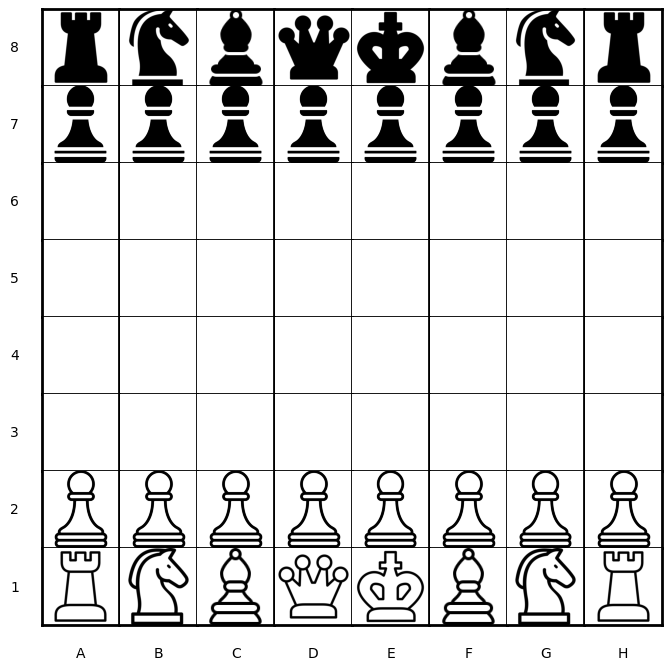

In [23]:
toon_bord(bord)

In [8]:
def test_move(orig, dest):

    column_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7}
    row_map = {'1': 7, '2': 6, '3': 5, '4': 4, '5': 3, '6': 2, '7': 1, '8': 0}

    try: 
        orig_pos = [row_map[orig[1]], column_map[orig[0]]]
        print(f"Origin position: {orig_pos}")
    except:
        print("Origin position: invalid")

    try:
        dest_pos = [row_map[dest[1]], column_map[dest[0]]]
        print(f"Destination position: {dest_pos}")
    except:
        print("Destination position: invalid")

In [9]:
test_move('K3', 'F8')

Origin position: invalid
Destination position: [0, 5]


In [30]:
def doe_zet(bord, kleur, van, naar):

    volgend_bord = [rij[:] for rij in bord]
    
    column_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7}
    row_map = {'1': 7, '2': 6, '3': 5, '4': 4, '5': 3, '6': 2, '7': 1, '8': 0}

    van_rij = row_map[van[1]]
    van_kol = column_map[van[0]]

    naar_rij = row_map[naar[1]]
    naar_kol = column_map[naar[0]]

    if naar_rij == 4 or naar_rij == 5:
        rij = 'juist'
    else:
        rij = 'fout'

    if naar_kol == van_kol:
        kol = 'juist'
    else:
        kol = 'fout'

    if rij == 'juist' and kol == 'juist':
        volgend_bord[naar_rij][naar_kol] = bord[van_rij][van_kol]
        volgend_bord[van_rij][van_kol] = 'leeg'
        
        toon_bord(volgend_bord)

    else:
        print('Foute zet!!')
    
    return volgend_bord

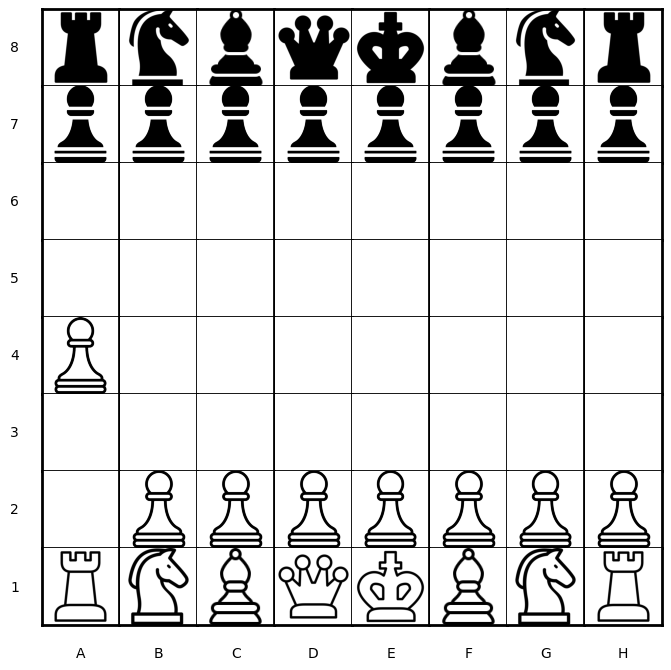

In [34]:
bord = doe_zet(bord, 'wit', 'A2', 'A4')